In [27]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from sklearn.preprocessing import MinMaxScaler
np.random.seed(42)

# Agglomerative clustering

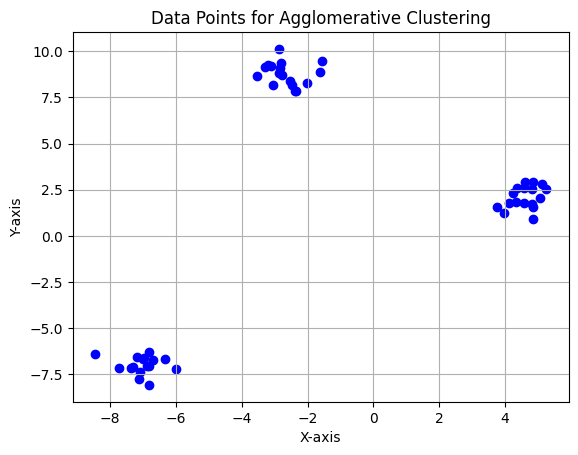

In [21]:
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.6, random_state=42)

# visualize X
plt.scatter(X[:, 0], X[:, 1], c='blue', marker='o')
plt.title('Data Points for Agglomerative Clustering')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()

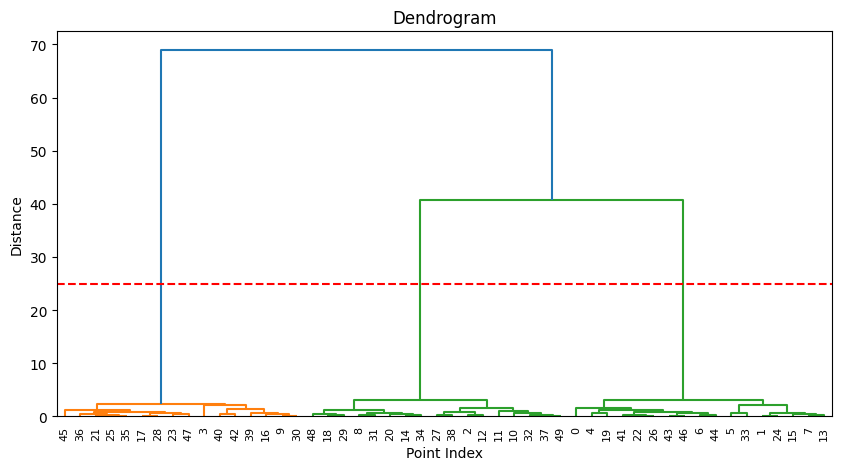

In [22]:
# Compute linkage
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.axhline(y=25, color='r', linestyle='--') # The "Cut"
plt.title("Dendrogram")
plt.xlabel("Point Index")
plt.ylabel("Distance")
plt.show()

## Different linkage methods (measure of distance between clusters)

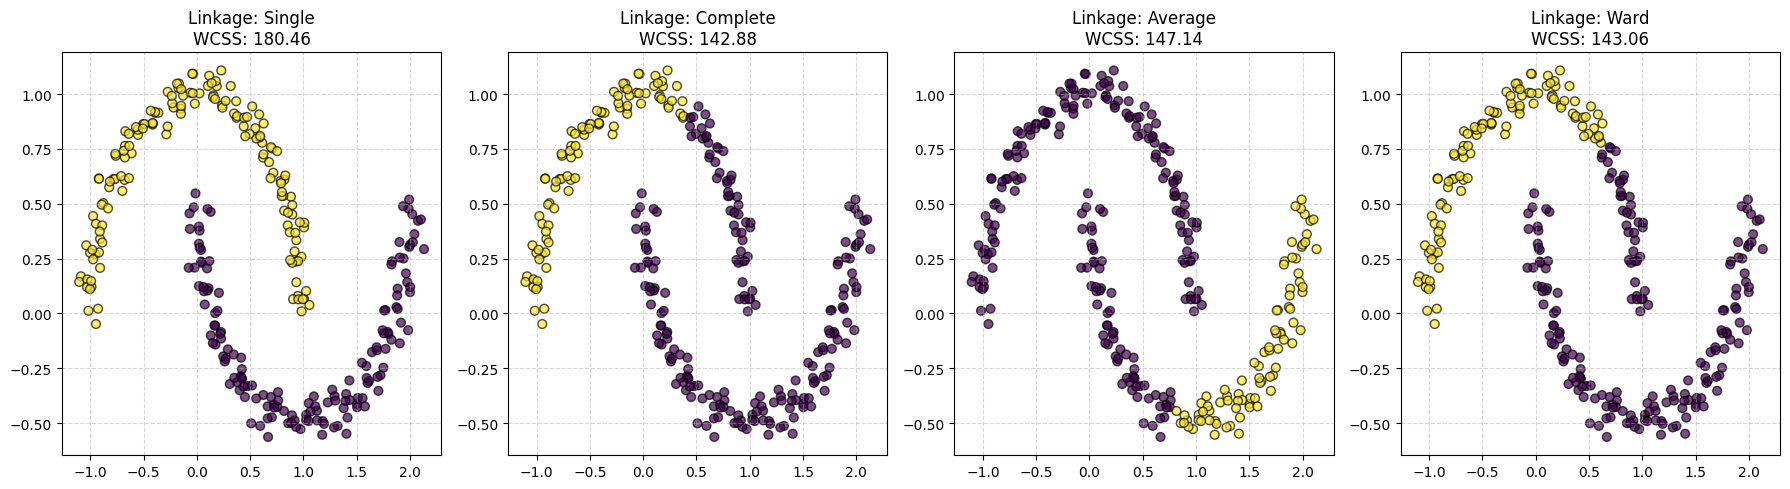

In [23]:
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(18, 5))

for i, link in enumerate(methods):
    model = AgglomerativeClustering(n_clusters=2, linkage=link)
    labels = model.fit_predict(X)

    # WCSS (within cluster sum of squares)
    wcss = 0
    for cluster_id in range(2):
        cluster_points = X[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)

    plt.subplot(1, 4, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, edgecolors='k', alpha=0.7)
    plt.title(f"Linkage: {link.capitalize()}\nWCSS: {wcss:.2f}")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Even though Ward's method minimizes the WCSS, the single linkage method captures the moon shapes much better. Ward's method is greedy and focuses on minimizing the variance within clusters, which can lead to poor performance on non-circular shapes. Single linkage, on the other hand, considers the minimum distance between points in different clusters, allowing it to capture the elongated shapes of the moons effectively.

## Where agglomerative clustering succeeds and fails

In [28]:
# donut-shaped data
X_circles, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
X_circles = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_circles)

# parallel lines
line1 = np.column_stack((np.linspace(0, 10, 200), np.zeros(200)))
line2 = np.column_stack((np.linspace(0, 10, 200), np.ones(200) * 2))
X_lines = np.vstack((line1, line2))
X_lines = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_lines)


# differently sized clusters
normal_data = np.random.normal(loc=10, scale=3, size=(50, 2))
anomaly_data = np.random.normal(loc=15, scale=0.5, size=(20, 2))
X_sizes = np.vstack((normal_data, anomaly_data))
X_sizes = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_sizes)

# moons
X_moon, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X_moon = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_moon)

# outliers
X_outlier, _ = make_blobs(n_samples=50, centers=1, cluster_std=0.5, random_state=42)
X_outlier = np.vstack([X_outlier, [10, 10]]) # Add a far outlier
X_outlier = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_outlier)

### Single linkage

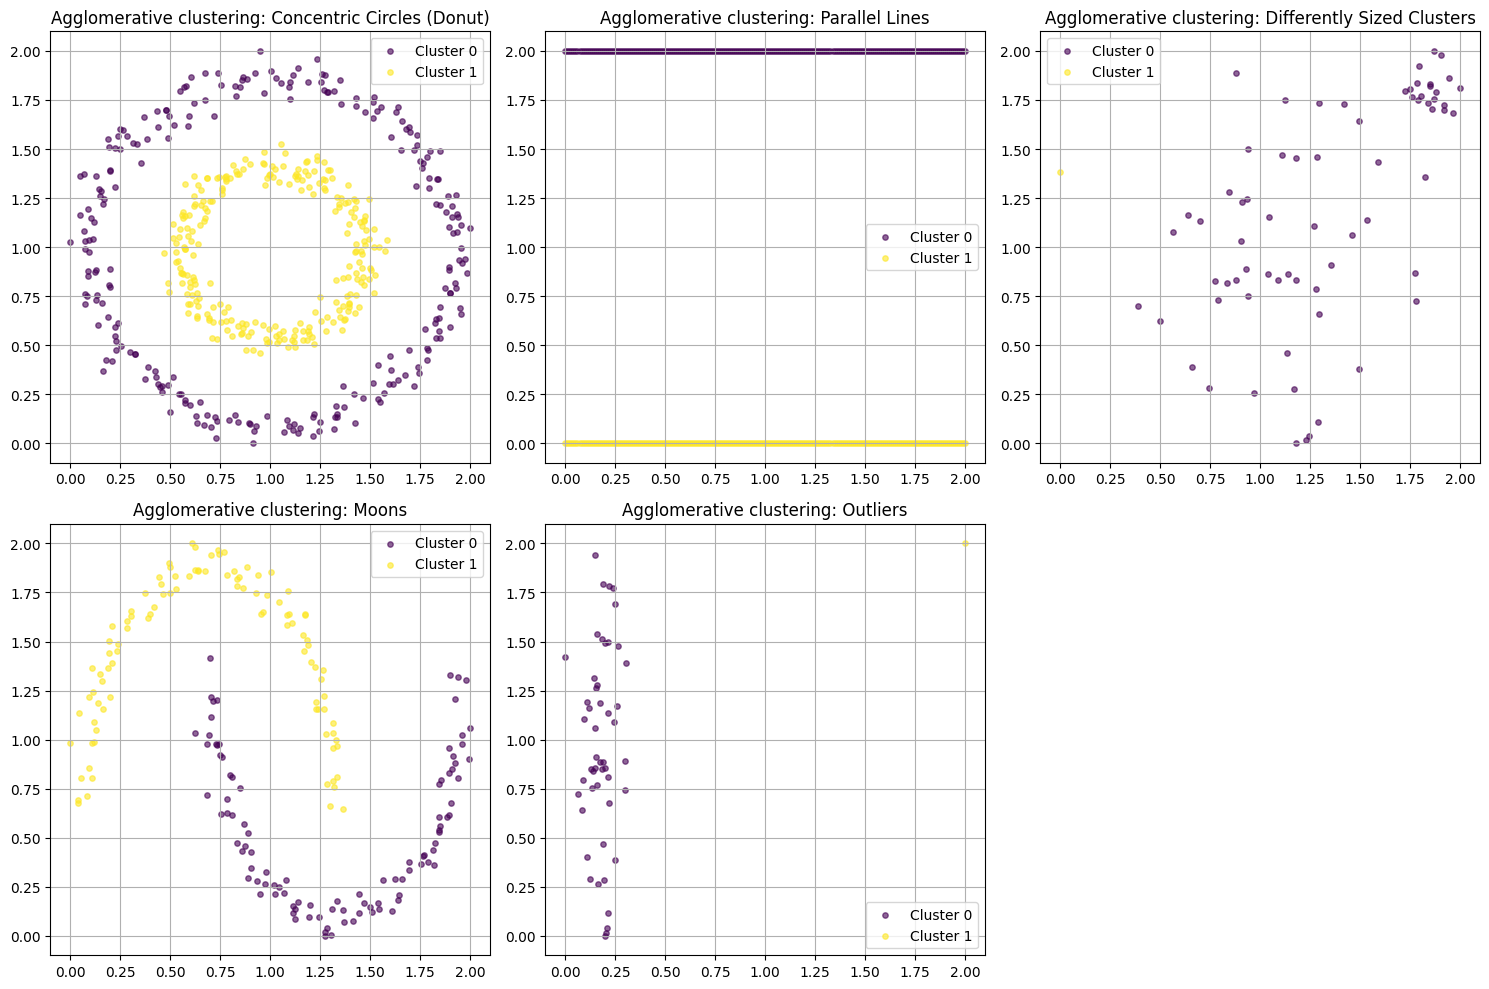

In [29]:
scenarios = [
    ("Concentric Circles (Donut)", X_circles, 2),
    ("Parallel Lines", X_lines, 2),
    ("Differently Sized Clusters", X_sizes, 2),
    ("Moons", X_moon, 2),
    ("Outliers", X_outlier, 2)
]

plt.figure(figsize=(15, 10))

for i, (name, X, k) in enumerate(scenarios):
    # n_init='auto' handles modern scikit-learn defaults (often 10)
    model = AgglomerativeClustering(n_clusters=2, linkage='single')
    y_pred = model.fit_predict(X)

    plt.subplot(2, 3, i + 1)

    # Use different colors for predicted clusters
    colors = plt.cm.viridis(np.linspace(0, 1, k))
    for label, color in zip(range(k), colors):
        plt.scatter(X[y_pred == label, 0], X[y_pred == label, 1], color=color, alpha=0.6, s=15, label=f'Cluster {label}')

    plt.title(f"Agglomerative clustering: {name}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Ward's method

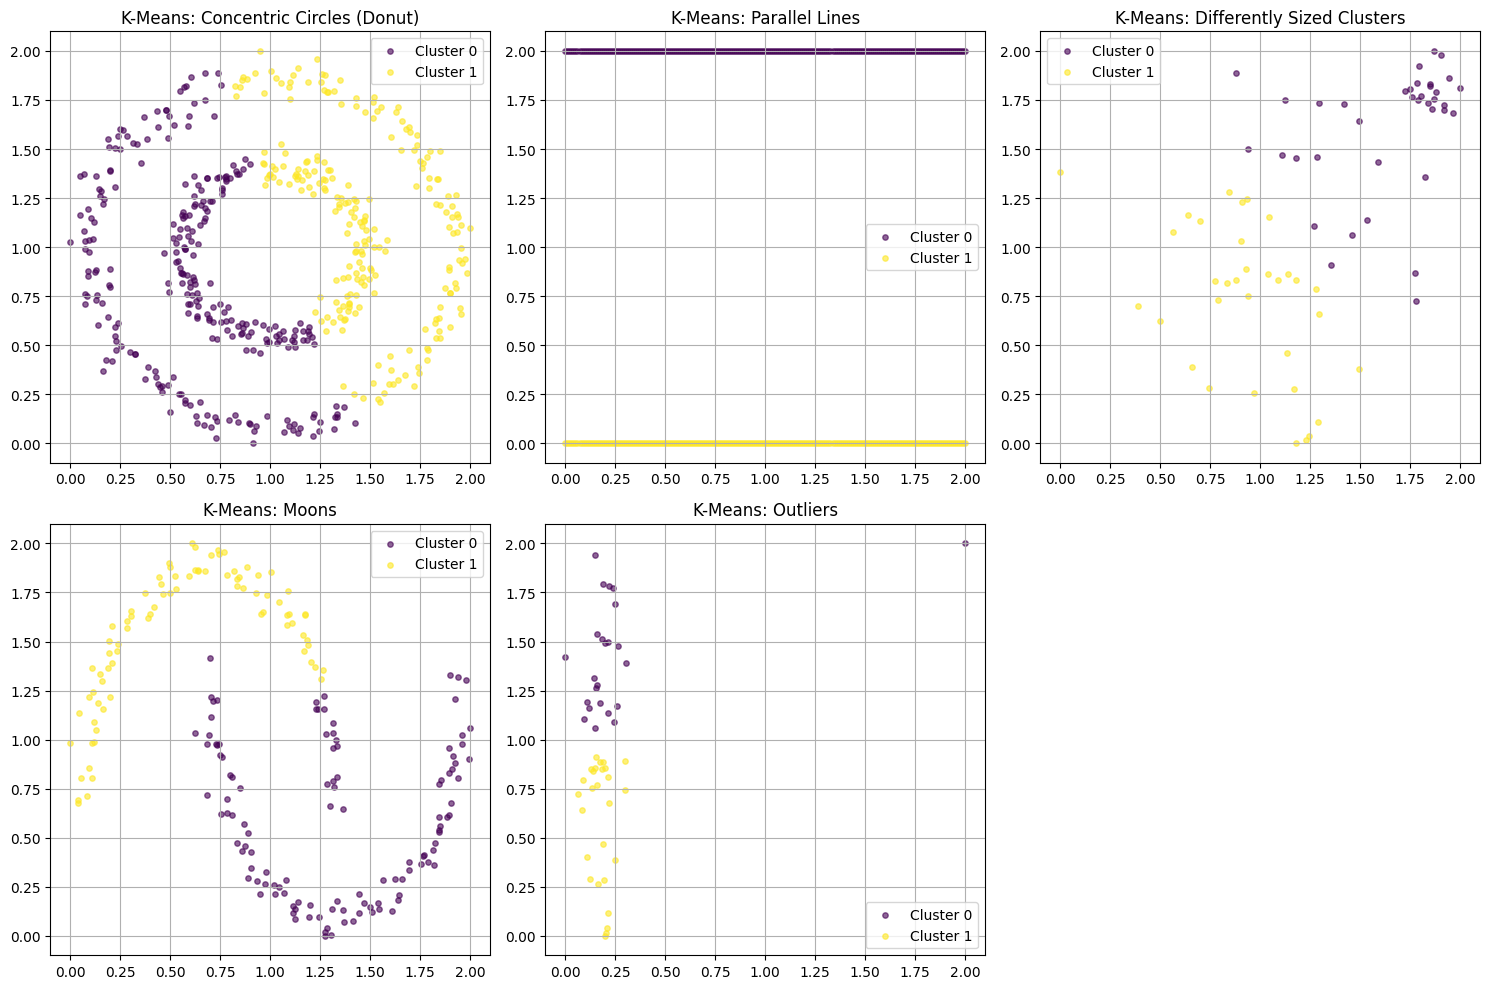

In [30]:
scenarios = [
    ("Concentric Circles (Donut)", X_circles, 2),
    ("Parallel Lines", X_lines, 2),
    ("Differently Sized Clusters", X_sizes, 2),
    ("Moons", X_moon, 2),
    ("Outliers", X_outlier, 2)
]

plt.figure(figsize=(15, 10))

for i, (name, X, k) in enumerate(scenarios):
    # n_init='auto' handles modern scikit-learn defaults (often 10)
    model = AgglomerativeClustering(n_clusters=2, linkage='ward')
    y_pred = model.fit_predict(X)

    plt.subplot(2, 3, i + 1)

    # Use different colors for predicted clusters
    colors = plt.cm.viridis(np.linspace(0, 1, k))
    for label, color in zip(range(k), colors):
        plt.scatter(X[y_pred == label, 0], X[y_pred == label, 1], color=color, alpha=0.6, s=15, label=f'Cluster {label}')

    plt.title(f"K-Means: {name}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()